In [28]:
import os

BASE_DIR = "dataset_split"

print(os.listdir(BASE_DIR))

['test', 'train', 'val']


In [29]:
TRAIN_DIR = os.path.join(BASE_DIR, "train")

print(os.listdir(TRAIN_DIR))

['images', 'train.csv']


In [30]:
for item in os.listdir(TRAIN_DIR):
    path = os.path.join(TRAIN_DIR, item)
    print(item, "->", "folder" if os.path.isdir(path) else "file")

images -> folder
train.csv -> file


In [31]:
IMAGE_DIR = os.path.join(TRAIN_DIR, "images")

print("Number of files:", len(os.listdir(IMAGE_DIR)))
print("First 10 files:")

for f in os.listdir(IMAGE_DIR)[:10]:
    print(f)

Number of files: 13015
First 10 files:
img00001.jpg
img00002.jpg
img00003.jpg
img00004.jpg
img00005.jpg
img00006.jpg
img00007.jpg
img00008.jpg
img00009.jpg
img00010.jpg


In [32]:
for f in os.listdir(TRAIN_DIR):
    if f.lower().endswith((".xlsx", ".xls", ".csv")):
        print(f)

train.csv


In [33]:
import pandas as pd
import os

METADATA_PATH = os.path.join(TRAIN_DIR, "train.csv")

df = pd.read_csv(METADATA_PATH)

print("Shape:", df.shape)
print(df.columns.tolist())

Shape: (13015, 34)
['image_id', 'patient_id', 'camera', 'patient_age', 'comorbidities', 'diabetes_time_y', 'insuline', 'patient_sex', 'exam_eye', 'diabetes', 'nationality', 'optic_disc', 'vessels', 'macula', 'DR_SDRG', 'DR_ICDR', 'focus', 'Illuminaton', 'image_field', 'artifacts', 'diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc', 'other', 'quality']


In [34]:
print(df[["image_id", "patient_id", "exam_eye"]].head(20))

    image_id  patient_id  exam_eye
0   img00001           1         1
1   img00002           1         2
2   img00003           2         1
3   img00004           2         2
4   img00005           3         1
5   img00006           3         2
6   img00007           4         1
7   img00008           4         2
8   img00009           5         1
9   img00010           5         2
10  img00011           6         1
11  img00012           6         2
12  img00013           7         1
13  img00014           7         2
14  img00015           8         1
15  img00016           8         2
16  img00019          10         1
17  img00020          10         2
18  img00021          11         1
19  img00022          11         2


In [35]:
print("\nEye distribution:")
print(df["exam_eye"].value_counts())


Eye distribution:
exam_eye
1    6530
2    6485
Name: count, dtype: int64


In [74]:
print("\nNumber of unique patients:")
print(df["patient_id"].nunique())


Number of unique patients:
6819


In [37]:
print("Shape:", df.shape)
print(df.columns.tolist())
print(df[["image_id", "patient_id", "exam_eye"]].head(20))
print(df["exam_eye"].value_counts())
print("Unique patients:", df["patient_id"].nunique())

Shape: (13015, 34)
['image_id', 'patient_id', 'camera', 'patient_age', 'comorbidities', 'diabetes_time_y', 'insuline', 'patient_sex', 'exam_eye', 'diabetes', 'nationality', 'optic_disc', 'vessels', 'macula', 'DR_SDRG', 'DR_ICDR', 'focus', 'Illuminaton', 'image_field', 'artifacts', 'diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc', 'other', 'quality']
    image_id  patient_id  exam_eye
0   img00001           1         1
1   img00002           1         2
2   img00003           2         1
3   img00004           2         2
4   img00005           3         1
5   img00006           3         2
6   img00007           4         1
7   img00008           4         2
8   img00009           5         1
9   img00010           5         2
10  img00011           6         1
11  img00012           6         2
12  img00013           7         1
13  img

In [38]:
eye_presence = df.groupby("patient_id")["exam_eye"].apply(set)

bilateral_patients = eye_presence[
    eye_presence.apply(lambda x: {1, 2}.issubset(x))
]

single_eye_patients = eye_presence[
    ~eye_presence.apply(lambda x: {1, 2}.issubset(x))
]

print("Total unique patients:", len(eye_presence))
print("Bilateral patients:", len(bilateral_patients))
print("Single-eye patients:", len(single_eye_patients))

Total unique patients: 6819
Bilateral patients: 6094
Single-eye patients: 725


In [39]:
eye_image_counts = (
    df.groupby(["patient_id", "exam_eye"])
      .size()
      .reset_index(name="image_count")
)

print(eye_image_counts["image_count"].value_counts())

image_count
1    12812
2      100
3        1
Name: count, dtype: int64


In [40]:
duplicate_patients = (
    eye_image_counts[
        eye_image_counts["image_count"] > 1
    ]["patient_id"]
    .unique()
)

print("Patients affected by duplicate-eye images:",
      len(duplicate_patients))

Patients affected by duplicate-eye images: 95


In [41]:
clean_eye_counts = eye_image_counts[
    eye_image_counts["image_count"] == 1
]

clean_bilateral = (
    clean_eye_counts
    .groupby("patient_id")
    .size()
)

clean_bilateral_patients = clean_bilateral[
    clean_bilateral == 2
]

print("Clean bilateral patients:",
      len(clean_bilateral_patients))

Clean bilateral patients: 6082


In [42]:
print(df[["image_id", "patient_id", "exam_eye"]].head(20))

    image_id  patient_id  exam_eye
0   img00001           1         1
1   img00002           1         2
2   img00003           2         1
3   img00004           2         2
4   img00005           3         1
5   img00006           3         2
6   img00007           4         1
7   img00008           4         2
8   img00009           5         1
9   img00010           5         2
10  img00011           6         1
11  img00012           6         2
12  img00013           7         1
13  img00014           7         2
14  img00015           8         1
15  img00016           8         2
16  img00019          10         1
17  img00020          10         2
18  img00021          11         1
19  img00022          11         2


In [43]:
# Keep only patient-eye combinations that have exactly one image
clean_eye_counts = eye_image_counts[
    eye_image_counts["image_count"] == 1
]

# Get the patient IDs that have exactly one image for BOTH eyes
clean_bilateral_ids = (
    clean_eye_counts
    .groupby("patient_id")
    .size()
)

clean_bilateral_ids = clean_bilateral_ids[
    clean_bilateral_ids == 2
].index

print("Clean bilateral patients:", len(clean_bilateral_ids))

Clean bilateral patients: 6082


In [44]:
bilateral_df = df[
    df["patient_id"].isin(clean_bilateral_ids)
].copy()

print("Images:", len(bilateral_df))
print("Patients:", bilateral_df["patient_id"].nunique())

Images: 12164
Patients: 6082


In [45]:
pairs_df = bilateral_df.pivot(
    index="patient_id",
    columns="exam_eye",
    values="image_id"
).reset_index()

In [46]:
pairs_df = pairs_df.rename(columns={
    1: "right_image_id",
    2: "left_image_id"
})

In [47]:
print(pairs_df.head(10))

exam_eye  patient_id right_image_id left_image_id
0                  1       img00001      img00002
1                  2       img00003      img00004
2                  3       img00005      img00006
3                  4       img00007      img00008
4                  5       img00009      img00010
5                  6       img00011      img00012
6                  7       img00013      img00014
7                  8       img00015      img00016
8                 10       img00019      img00020
9                 11       img00021      img00022


In [48]:
print("Number of pairs:", len(pairs_df))

print(
    "Missing right:",
    pairs_df["right_image_id"].isna().sum()
)

print(
    "Missing left:",
    pairs_df["left_image_id"].isna().sum()
)

Number of pairs: 6082
Missing right: 0
Missing left: 0


In [49]:
IMAGE_DIR = os.path.join(TRAIN_DIR, "images")

def get_image_path(image_id):
    image_id = str(image_id)

    for ext in [".jpg", ".jpeg", ".png", ""]:
        path = os.path.join(IMAGE_DIR, image_id + ext)
        if os.path.isfile(path):
            return path

    return None


missing_images = []

for _, row in pairs_df.iterrows():

    right_path = get_image_path(row["right_image_id"])
    left_path = get_image_path(row["left_image_id"])

    if right_path is None:
        missing_images.append(
            (row["patient_id"], row["right_image_id"], "right")
        )

    if left_path is None:
        missing_images.append(
            (row["patient_id"], row["left_image_id"], "left")
        )

print("Total bilateral patients:", len(pairs_df))
print("Expected images:", len(pairs_df) * 2)
print("Missing images:", len(missing_images))

if missing_images:
    print("\nFirst missing images:")
    print(missing_images[:10])

Total bilateral patients: 6082
Expected images: 12164
Missing images: 0


In [50]:
import os

TEST_OUTPUT = "BRSET_processed_test/train"

os.makedirs(TEST_OUTPUT, exist_ok=True)

print(TEST_OUTPUT)

BRSET_processed_test/train


In [51]:
test_pairs = pairs_df.head(10).copy()

print(test_pairs)

exam_eye  patient_id right_image_id left_image_id
0                  1       img00001      img00002
1                  2       img00003      img00004
2                  3       img00005      img00006
3                  4       img00007      img00008
4                  5       img00009      img00010
5                  6       img00011      img00012
6                  7       img00013      img00014
7                  8       img00015      img00016
8                 10       img00019      img00020
9                 11       img00021      img00022


In [52]:
from PIL import Image
import matplotlib.pyplot as plt

patient = test_pairs.iloc[0]

right_path = get_image_path(patient["right_image_id"])
left_path = get_image_path(patient["left_image_id"])

right_img = Image.open(right_path)
left_img = Image.open(left_path)

print("Patient:", patient["patient_id"])
print("Right:", right_img.size)
print("Left:", left_img.size)

Patient: 1
Right: (990, 874)
Left: (951, 874)


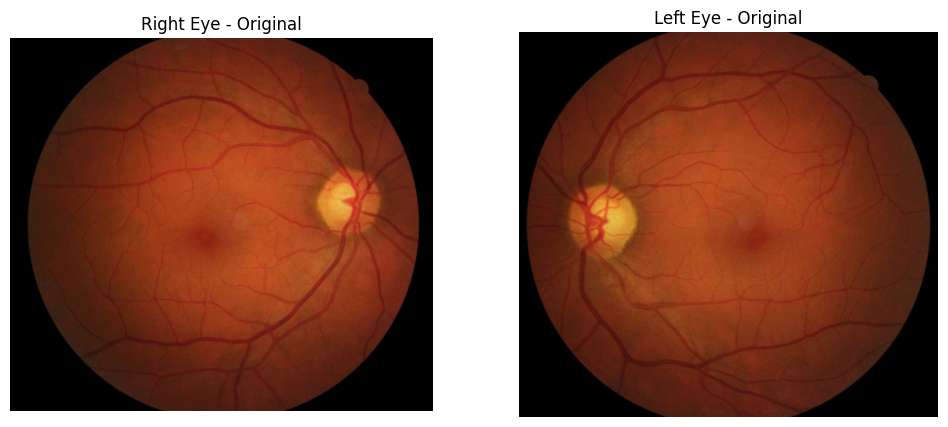

In [53]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(right_img)
plt.title("Right Eye - Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(left_img)
plt.title("Left Eye - Original")
plt.axis("off")

plt.show()

In [54]:
import numpy as np
from PIL import Image


def crop_fundus_fov(image, threshold=10):
    """Remove the black border and isolate the circular retinal field of view."""
    img = np.array(image.convert("RGB"))
    gray = np.mean(img, axis=2)
    foreground = gray > threshold
    ys, xs = np.where(foreground)

    if len(xs) == 0:
        return image.convert("RGB")

    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    fundus = img[y_min:y_max + 1, x_min:x_max + 1]

    height, width = fundus.shape[:2]
    center_x = width / 2.0
    center_y = height / 2.0
    radius = min(width, height) / 2.0

    # Keep a small edge margin while ensuring the crop stays inside the image.
    radius *= 0.98
    side = int(2 * radius)
    left = max(0, int(round(center_x - radius)))
    top = max(0, int(round(center_y - radius)))
    left = min(left, width - side)
    top = min(top, height - side)
    cropped = fundus[top:top + side, left:left + side].copy()

    y_grid, x_grid = np.ogrid[:side, :side]
    circle_mask = (x_grid - side / 2.0) ** 2 + (y_grid - side / 2.0) ** 2 <= radius ** 2
    cropped[~circle_mask] = 0

    return Image.fromarray(cropped)

In [55]:
right_cropped = crop_fundus_fov(right_img)
left_cropped = crop_fundus_fov(left_img)

print("Original right:", right_img.size)
print("Cropped right:", right_cropped.size)

print("Original left:", left_img.size)
print("Cropped left:", left_cropped.size)

Original right: (990, 874)
Cropped right: (856, 856)
Original left: (951, 874)
Cropped left: (856, 856)


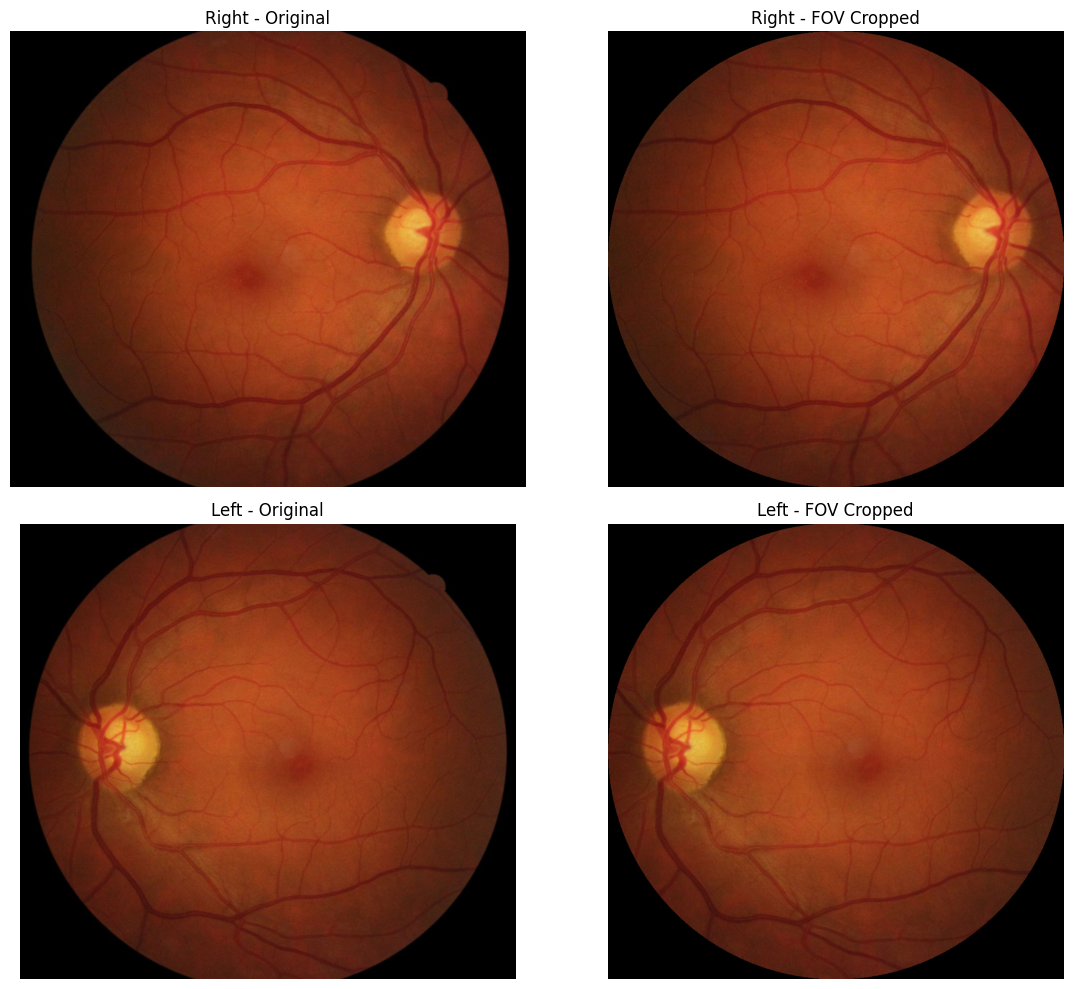

In [56]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(right_img)
plt.title("Right - Original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(right_cropped)
plt.title("Right - FOV Cropped")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(left_img)
plt.title("Left - Original")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(left_cropped)
plt.title("Left - FOV Cropped")
plt.axis("off")

plt.tight_layout()
plt.show()

In [57]:
import cv2
import numpy as np
from PIL import Image

In [58]:
def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    Apply CLAHE to the luminance channel of an RGB fundus image.
    """

    img = np.array(image.convert("RGB"))

    # RGB → LAB
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    # Separate LAB channels
    l, a, b = cv2.split(lab)

    # CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )

    l_enhanced = clahe.apply(l)

    # Merge channels
    lab_enhanced = cv2.merge(
        [l_enhanced, a, b]
    )

    # LAB → RGB
    rgb_enhanced = cv2.cvtColor(
        lab_enhanced,
        cv2.COLOR_LAB2RGB
    )

    return Image.fromarray(rgb_enhanced)

In [59]:
right_clahe = apply_clahe(right_cropped)
left_clahe = apply_clahe(left_cropped)

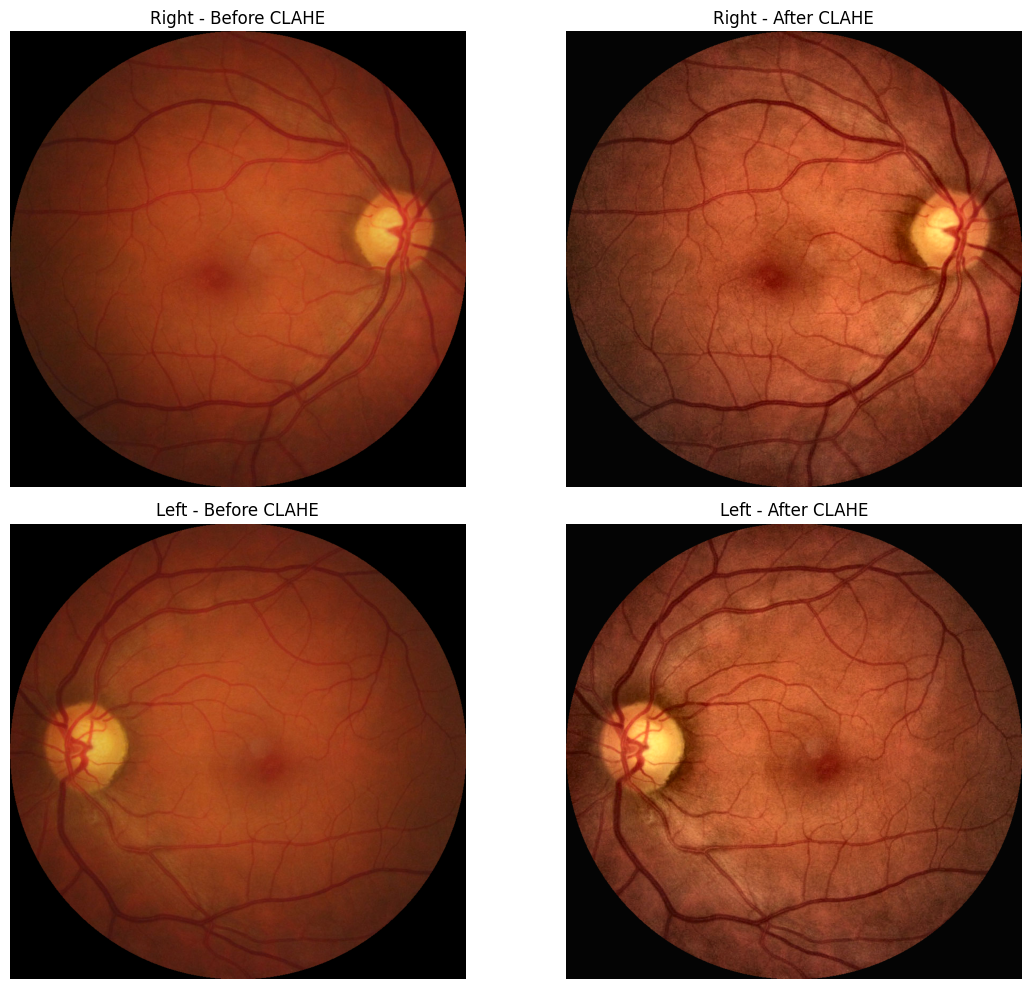

In [60]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(right_cropped)
plt.title("Right - Before CLAHE")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(right_clahe)
plt.title("Right - After CLAHE")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(left_cropped)
plt.title("Left - Before CLAHE")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(left_clahe)
plt.title("Left - After CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

In [61]:
def preprocess_fundus(image):

    # 1. Circular retina crop
    image = crop_fundus_fov(image)

    # 2. CLAHE
    image = apply_clahe(
        image,
        clip_limit=2.0,
        tile_grid_size=(8, 8)
    )

    # 3. Fixed size for OD/vessel models
    image = image.resize(
        (384, 384),
        Image.Resampling.LANCZOS
    )

    return image

In [62]:
right_processed = preprocess_fundus(right_img)
left_processed = preprocess_fundus(left_img)

In [63]:
print(right_processed.size)
print(left_processed.size)

(384, 384)
(384, 384)


In [64]:
PILOT_OUTPUT = "BRSET_processed_test/train"

os.makedirs(PILOT_OUTPUT, exist_ok=True)

In [65]:
from PIL import Image
import os

for _, row in test_pairs.iterrows():

    patient_id = str(row["patient_id"])

    # Patient output folder
    patient_dir = os.path.join(PILOT_OUTPUT, patient_id)
    os.makedirs(patient_dir, exist_ok=True)

    # Get source paths
    right_path = get_image_path(row["right_image_id"])
    left_path = get_image_path(row["left_image_id"])

    # Load
    right_img = Image.open(right_path).convert("RGB")
    left_img = Image.open(left_path).convert("RGB")

    # Preprocess
    right_processed = preprocess_fundus(right_img)
    left_processed = preprocess_fundus(left_img)

    # Save
    right_processed.save(
        os.path.join(patient_dir, "right.jpg"),
        quality=95
    )

    left_processed.save(
        os.path.join(patient_dir, "left.jpg"),
        quality=95
    )

print("Pilot preprocessing complete!")

Pilot preprocessing complete!


In [66]:
def validate_dataset(root):

    patients = [

        p for p in os.listdir(root)

        if os.path.isdir(os.path.join(root, p))

    ]



    errors = []



    for patient_id in patients:



        patient_dir = os.path.join(root, patient_id)



        left_path = os.path.join(patient_dir, "left.jpg")

        right_path = os.path.join(patient_dir, "right.jpg")



        # Check files

        if not os.path.isfile(left_path):

            errors.append((patient_id, "missing left"))



        if not os.path.isfile(right_path):

            errors.append((patient_id, "missing right"))



        # Check dimensions and RGB

        if os.path.isfile(left_path):

            img = Image.open(left_path)



            if img.size != (384, 384):

                errors.append((patient_id, "left wrong size"))



            if img.mode != "RGB":

                errors.append((patient_id, "left not RGB"))



        if os.path.isfile(right_path):

            img = Image.open(right_path)



            if img.size != (384, 384):

                errors.append((patient_id, "right wrong size"))



            if img.mode != "RGB":

                errors.append((patient_id, "right not RGB"))



    print("Patients:", len(patients))

    print("Expected images:", len(patients) * 2)

    print("Errors:", len(errors))



    if errors:

        print(errors[:20])

    else:

        print("Dataset validation passed!")

In [67]:
validate_dataset(PILOT_OUTPUT)

Patients: 10
Expected images: 20
Errors: 0
Dataset validation passed!


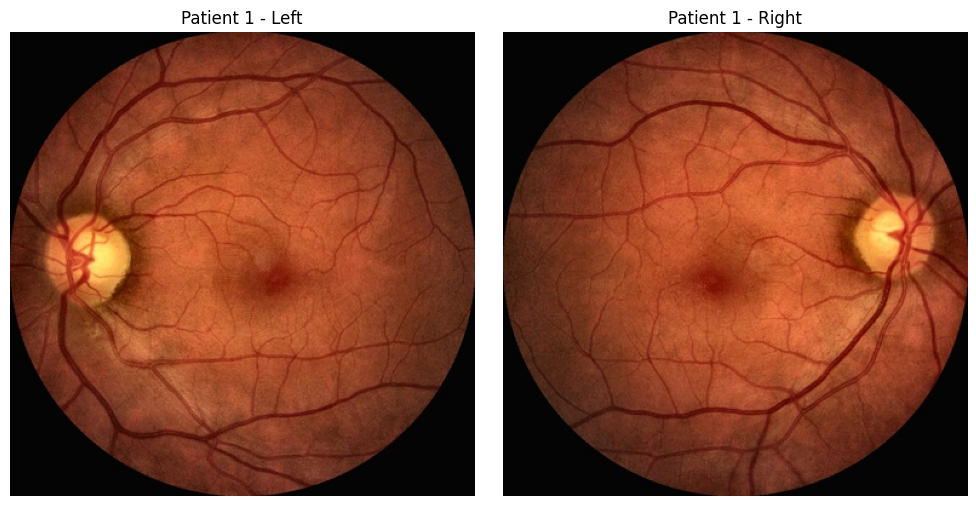

In [68]:
patient_id = str(test_pairs.iloc[0]["patient_id"])

left_path = os.path.join(
    PILOT_OUTPUT, patient_id, "left.jpg"
)

right_path = os.path.join(
    PILOT_OUTPUT, patient_id, "right.jpg"
)

left_final = Image.open(left_path)
right_final = Image.open(right_path)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(left_final)
plt.title(f"Patient {patient_id} - Left")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(right_final)
plt.title(f"Patient {patient_id} - Right")
plt.axis("off")

plt.tight_layout()
plt.show()

In [69]:
FINAL_OUTPUT = "BRSET_processed/train"

os.makedirs(FINAL_OUTPUT, exist_ok=True)

In [70]:
from tqdm import tqdm



processed_count = 0

skipped_count = 0

errors = []



for _, row in tqdm(

    pairs_df.iterrows(),

    total=len(pairs_df),

    desc="Processing bilateral patients"

):

    patient_id = str(row["patient_id"])

    patient_dir = os.path.join(FINAL_OUTPUT, patient_id)

    left_output = os.path.join(patient_dir, "left.jpg")

    right_output = os.path.join(patient_dir, "right.jpg")



    outputs_are_current = False

    if os.path.isfile(left_output) and os.path.isfile(right_output):

        try:

            outputs_are_current = (

                Image.open(left_output).size == (384, 384)

                and Image.open(right_output).size == (384, 384)

            )

        except Exception:

            outputs_are_current = False



    if outputs_are_current:

        skipped_count += 1

        continue



    try:

        os.makedirs(patient_dir, exist_ok=True)



        right_path = get_image_path(row["right_image_id"])

        left_path = get_image_path(row["left_image_id"])



        if right_path is None or left_path is None:

            raise FileNotFoundError(

                f"Missing source image: right={right_path}, left={left_path}"

            )



        right_img = Image.open(right_path).convert("RGB")

        left_img = Image.open(left_path).convert("RGB")



        preprocess_fundus(right_img).save(right_output, quality=95)

        preprocess_fundus(left_img).save(left_output, quality=95)

        processed_count += 1



    except Exception as e:

        errors.append({"patient_id": patient_id, "error": str(e)})



print("\nDone")

print("Newly processed:", processed_count)

print("Already existed:", skipped_count)

print("Errors:", len(errors))



if errors:

    print(errors[:10])

Processing bilateral patients:   0%|          | 0/6082 [00:00<?, ?it/s]

Processing bilateral patients: 100%|██████████| 6082/6082 [58:02<00:00,  1.75it/s]  


Done
Newly processed: 6082
Already existed: 0
Errors: 0


In [71]:
validate_dataset(FINAL_OUTPUT)

Patients: 6082
Expected images: 12164
Errors: 0
Dataset validation passed!


In [72]:
import os

patients = [
    p for p in os.listdir(FINAL_OUTPUT)
    if os.path.isdir(os.path.join(FINAL_OUTPUT, p))
]

print("Number of patient folders:", len(patients))

# Show first 5
for patient in patients[:5]:
    patient_dir = os.path.join(FINAL_OUTPUT, patient)
    print(patient, os.listdir(patient_dir))

Number of patient folders: 6082
1 ['left.jpg', 'right.jpg']
10 ['left.jpg', 'right.jpg']
1000 ['left.jpg', 'right.jpg']
1001 ['left.jpg', 'right.jpg']
1002 ['left.jpg', 'right.jpg']


In [73]:
# Export the original schema after keeping only complete bilateral patient-eye pairs.
preprocessed_df = df[
    df["patient_id"].isin(clean_bilateral_ids)
].copy()

preprocessed_df["exam_eye"] = preprocessed_df["exam_eye"].replace({
    1: "right",
    2: "left",
    "1": "right",
    "2": "left",
})

if len(preprocessed_df.columns) != 34:
    raise ValueError(
        f"Expected the original 34-column schema, found {len(preprocessed_df.columns)} columns."
    )

OUTPUT_CSV = "preprocessed.csv"
preprocessed_df.to_csv(OUTPUT_CSV, index=False)

print(f"Saved: {OUTPUT_CSV}")
print(f"Rows: {len(preprocessed_df)}")
print(f"Columns: {len(preprocessed_df.columns)}")
print(f"Patients: {preprocessed_df['patient_id'].nunique()}")
print(f"exam_eye values: {sorted(preprocessed_df['exam_eye'].dropna().unique())}")

Saved: preprocessed.csv
Rows: 12164
Columns: 34
Patients: 6082
exam_eye values: ['left', 'right']
